# 23회차 기출문제 해답

## 문제 1

**Data description**

-   temperature : 온도(섭씨)

-   Humidity : 습도(%)

-   Light : 밝기(lux)

-   Co2 : 이산화탄소 농도(ppm)

-   Occupancy : 방 이용 유무

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score, plot_roc_curve, roc_auc_score, roc_curve
from sklearn import set_config
set_config(display="diagram")

In [2]:
dat = pd.read_csv('problem1.csv')

In [3]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  300 non-null    float64
 1   humidity     300 non-null    float64
 2   light        300 non-null    float64
 3   co2          295 non-null    float64
 4   occupancy    300 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [4]:
y = dat.occupancy
X = dat.drop(['occupancy'], axis = 1)

**1. 데이터를 탐색하고 탐색 결과를 제시하시오.**

In [5]:
dat.isna().sum()

temperature    0
humidity       0
light          0
co2            5
occupancy      0
dtype: int64

co2 변수에 결측치가 존재한다.

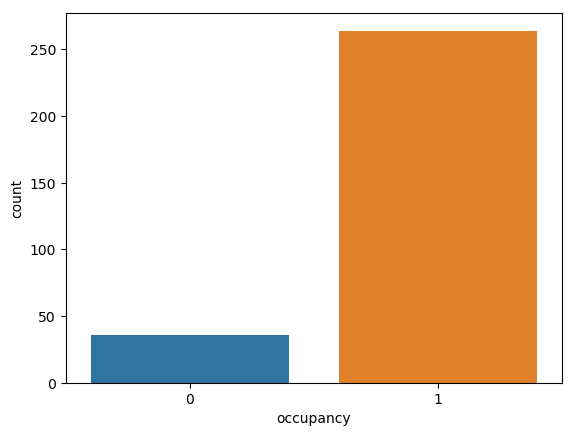

In [6]:
import warnings
warnings.filterwarnings('ignore')
sns.countplot(y);
plt.show();

occupancy 변수를 보면 방 이용을 안한 경우에 비해 이용을 한 경우가 매우 많다.

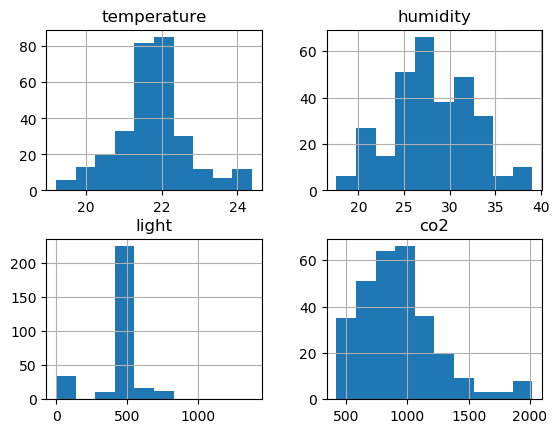

In [7]:
X.select_dtypes('number').hist();
plt.show();

light 변수를 보면 light = 0인 이상 케이스가 존재한다.

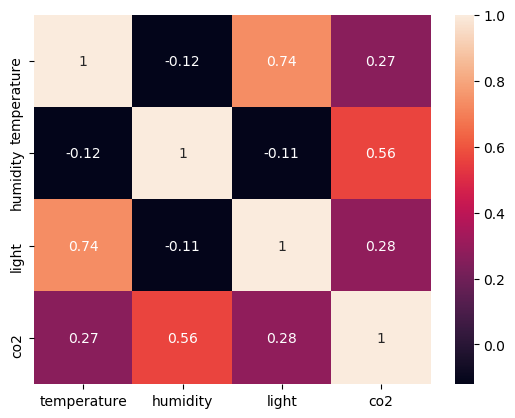

In [8]:
corr = X.select_dtypes('number').corr();
sns.heatmap(corr, annot = True);
plt.show();

(light, temperature), (light, humidity) 간에는 양의 상관관계가 존재한다.

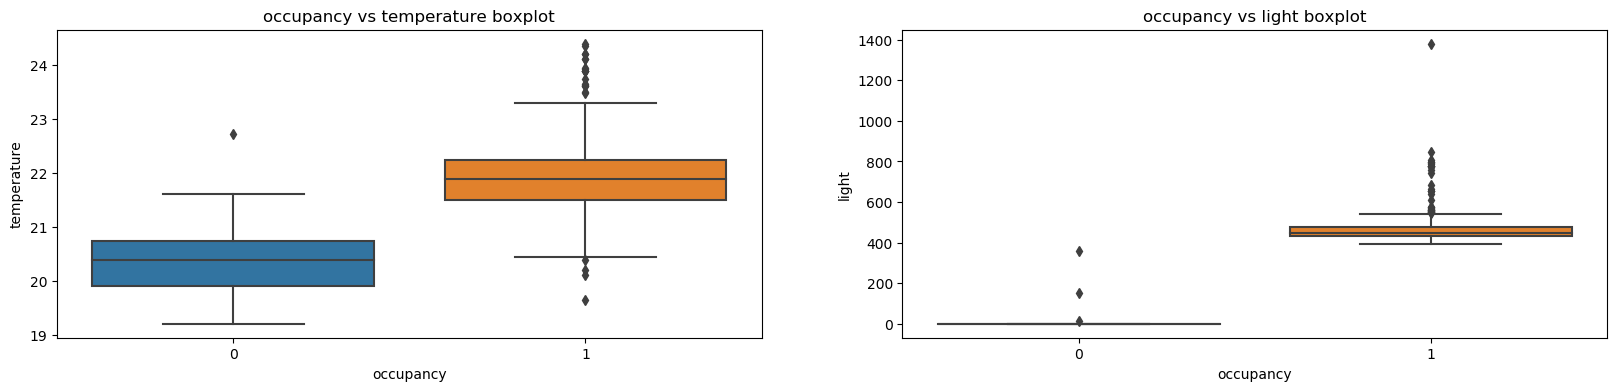

In [9]:
f, axes = plt.subplots(ncols = 2, figsize = (20,4));
sns.boxplot(x = "occupancy", y = "temperature", data = dat, ax = axes[0]);
axes[0].set_title('occupancy vs temperature boxplot');
sns.boxplot(x = "occupancy", y = "light", data = dat, ax = axes[1]);
axes[1].set_title('occupancy vs light boxplot');
plt.show();

In [10]:
dat.groupby(['occupancy'])['light'].agg(['min', 'mean', 'max'])

,min,mean,max
occupancy,,,
0,0.0,14.638889,360.0
1,393.0,480.435227,1380.0


방 이용을 안한 경우 light는 360이하이고, 방 이용을 한 경우 light는 393 이상인 것을 확인할 수 있다.

**2. 결측치를 탐색하고, 결측치 대치 방법 한 가지를 수행하고, 해당 방법을 사용한 근거를 제시하시오.**

EDA 결과 결측치는 co2 변수에 1.67% 존재한다.

결측치를 대치하기 전에 학습 데이터와 검증 데이터를 분할한다. 학습 데이터와 검증 데이터를 사전에 분할하는 이유는 최종 모형 평가에 활용되는 검증 데이터의 정보가 데이터 전처리 과정에서 활용되는 것을 방지 하기 위함이다.

In [11]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, random_state = 0)

Random forest를 활용하여 결측치를 대치한다. Random forest를 이용해서 결측치를 대치한 이유는 대표값을 이용하는 방법에 비해서 다른 변수의 정보를 이용해서 결측치를 대치할 수 있기 때문에 더 많은 정보를 활용해서 결측치를 대치할 수 있기 때문이다.

In [12]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

impute_preprocess = make_pipeline(
    IterativeImputer(estimator = RandomForestRegressor(), max_iter = 5)
)

preprocess = ColumnTransformer(
    [("imputation", impute_preprocess, X.columns)]
)
preprocess

ColumnTransformer(transformers=[('imputation',
                                 Pipeline(steps=[('iterativeimputer',
                                                  IterativeImputer(estimator=RandomForestRegressor(),
                                                                   max_iter=5))]),
                                 Index(['temperature', 'humidity', 'light', 'co2'], dtype='object'))])

In [13]:
imp_train_X = preprocess.fit_transform(train_X)
imp_test_X = preprocess.transform(test_X)

train_X = pd.DataFrame(imp_train_X, columns = X.columns)
test_X = pd.DataFrame(imp_test_X, columns = X.columns)

train_X.isna().sum()

temperature    0
humidity       0
light          0
co2            0
dtype: int64

결측치가 모두 대치된 것을 확인할 수 있다.

**3. 추가적으로 데이터 질을 향상시킬만한 내용을 작성하시오(구현 안하고 설명만해도 됨).**

연속형 변수에 대해 표준화를 고려할 수 있다. 표준화는 평균 0, 표준편차 1인 형태로 변환하는 방법이다. 표준화를 수행할 경우 모델의 학습 속도를 높이고, 수렴 속도를 개선할 수 있다.

**4. 데이터 불균형을 식별하고 불균형을 처리할 오버샘플링 기법 두 가지를 제시하시오.**

**simple oversampling**

오버샘플링은 소수 범주 내 관측치를 복원추출을 통해 새로운 데이터를 생성하는 방법이다.

In [14]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
oversample = RandomOverSampler(sampling_strategy='minority')
train_X_over, train_y_over = oversample.fit_resample(train_X, train_y)
print(Counter(train_y_over))

Counter({0: 211, 1: 211})


**SMOTE**

SMOTE(Synthetic Minority Over-sampling Technique)는 불균형한 데이터셋에서 소수 클래스의 데이터를 합성하여 클래스 간의 균형을 맞추는 오버샘플링 기법으로, 기존 데이터의 K-최근접 이웃(KNN)을 기반으로 새로운 데이터를 생성하는 방법이다.

In [15]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
train_X_smote, train_y_smote = smote.fit_resample(train_X, train_y)
print(Counter(train_y_smote))

Counter({0: 211, 1: 211})


**5. 오버샘플링한 데이터셋을 각각 제시하고, 오버샘플링 기법별 장·단점을 작성하시오.**

**simple oversampling**

**장점**

-   under sampling 처럼 데이터를 잃지 않고, 소수 범주를 잘 분류할 가능성이 있음

**단점**

-   소수 범주를 복원추출을 통해 값을 복제하므로, 소수 범주에 과적합될 수 있음

-   데이터의 크기가 증가하므로 모델 적합시 계산량이 더 많아짐

**SMOTE**

**장점**

-   under sampling 처럼 데이터를 잃지 않고, 소수 범주를 잘 분류할 가능성이 있음

-   관측치를 단순히 복제하는 것이 아니므로, Simple oversampling에 비해 과적합을 완화할 수 있음

**단점**

-   데이터의 크기가 증가하므로 모델 적합시 계산량이 더 많아짐

-   $k$값에 따라 성능이 유동적임

-   소수 클래스의 정보만 사용하므로, 다수 클래스에 대한 정보가 전혀 고려되지 않음

In [16]:
print('oversampling y:', Counter(train_y_over))
print('SMOTE y:', Counter(train_y_smote))

print('oversampling X:', train_X_over.shape)
print('SMOTE X:', train_X_over.shape)

oversampling y: Counter({0: 211, 1: 211})
SMOTE y: Counter({0: 211, 1: 211})
oversampling X: (422, 4)
SMOTE X: (422, 4)


**6. 오버샘플링 데이터셋을 이용해서 정확도 측면 모형과 속도 측면 모형을 각각 제시하시오.**

모델 튜닝은 파라미터의 범위를 제한하여 진행하였으며, 반복 5-fold 교차검증을 통해 validation 데이터를 여러번 생성 후 적합하여, 하이퍼파라미터별 모형 성능을 교차 검증하였다.

In [17]:
num_preprocess = make_pipeline(
    StandardScaler()
)

preprocess = ColumnTransformer(
    [("imputation", impute_preprocess, X.columns), 
     ("num", num_preprocess, X.columns)]
)

**Random forest**

Random forest는 Bagging을 의사결정나무에 적용하여 의사결정나무의 단점인 예측력의 분산이 큰 단점을 보완한 모형이다. Decision tree과 성능 비교를 위해 활용한다.

In [18]:
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline(
    [
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state = 0)),
        ("classifier", RandomForestClassifier())
    ]
)

In [19]:
RandomForest_param = {'classifier__max_features': np.arange(0.1, 1, 0.1)}
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

In [20]:
start_time = time.time()
RandomForest_search = GridSearchCV(estimator = pipe_rf, 
                      param_grid = RandomForest_param, 
                      cv = cv,
                      scoring = 'balanced_accuracy') # roc_auc, average_precision
RandomForest_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

print('Random Forest best score : ', RandomForest_search.best_score_)

24.358000993728638s
Random Forest best score :  0.9888888888888889


**Decision tree**

Decision tree는 나무구조를 활용한 의사결정 규칙을 통해서 분류 혹은 예측을 수행하는 방법이다. 범주형 변수의 경우 gini index, cross entropy, 연속형 변수의 경우 SSE를 활용하여, 데이터에 맞는 적절한 분할 기준을 구축하여 의사결정나무를 생성한다. 단일의사결정나무의 경우 시각화를 통해 모델 해석과 계산 속도가 빠르다는 장점이 있다.

In [21]:
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline(
    [
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state = 0)),
        ("classifier", DecisionTreeClassifier())
    ]
)

In [22]:
decisiontree_param = {'classifier__ccp_alpha': np.arange(0.1, 1, 0.1)}
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

start_time = time.time()
decisiontree_search = GridSearchCV(estimator = pipe_dt, 
                      param_grid = decisiontree_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
decisiontree_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

print('decision tree best score : ', decisiontree_search.best_score_)

21.72099733352661s
decision tree best score :  0.9888888888888889


**7. 둘 중 하나의 모형을 선택하고 분류 결과와 함께 이유를 제시하시오.**

두 모형 모두 balanced accuracy가 0.98이므로, 속도 측면에서 빠른 의사결정나무를 최종 모델로 선택한다.

In [23]:
pred = decisiontree_search.predict(test_X)
print(classification_report(test_y, pred))
print(balanced_accuracy_score(test_y, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        53

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

1.0


EDA 과정에서 살펴본 occupancy \~ light의 boxplot을 보면 occupancy에 따라 light가 완벽하게 분리되는 것을 확인할 수 있다. 따라서 이상치가 없다는 가정 하에 light 변수를 활용하면 모델을 이용하지 않아도 occupancy를 정확히 예측할 수 있다.

현재 수집된 데이터에서는 light 변수를 이용해서 occupancy를 완벽하게 설명할 수 있지만, 데이터가 더 수집되어 이상치가 존재할 경우(방이 비어있어도 light \> 400인 케이스) 모형을 통한 예측이 필요하며, 추가 변수가 수집되면 더 강건한 예측을 할 수 있을 것이다.

**8. 원데이터와 비교해서 오버샘플링이 미친 영향에 대해 작성하시오.**

In [24]:
pipe_dt2 = Pipeline(
    [
        ("preprocess", preprocess),
        #("smote", SMOTE(random_state = 0)),
        ("classifier", DecisionTreeClassifier())
    ]
)

In [25]:
start_time = time.time()
decisiontree_param = {'classifier__ccp_alpha': np.arange(0.1, 1, 0.1)}
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

start_time = time.time()
decisiontree_search = GridSearchCV(estimator = pipe_dt2, 
                      param_grid = decisiontree_param, 
                      cv = cv,
                      scoring = 'balanced_accuracy')
decisiontree_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

print('decision tree best score : ', decisiontree_search.best_score_)

18.948997497558594s
decision tree best score :  0.9888888888888889


In [26]:
pred = decisiontree_search.predict(test_X)
print(classification_report(test_y, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        53

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



light 변수를 이용해서 occupancy를 완벽하게 설명할 수 있으므로, 오버샘플링을 하지 않아도 balanced accuracy는 0.98이다.

## 문제 2

**1. ACF를 활용하여 distance를 계산하시오.**

::: callout-note
문제의 의도는 시계열 자료의 특성을 반영한 거리를 구하는 것입니다. 단순 유클리디안 거리의 경우 시계열 특성을 반영할 수 없으므로, ACF를 통해 시계열 특성을 반영한 후 유클리디안 거리를 계산합니다.

$$
\text{ACF distance}(X, Y) = \sqrt{\sum_{k=1}^{L} \left( \rho_X(k) - \rho_Y(k) \right)^2}
$$

-   $L$ 은 ACF를 계산할 최대 시차(lag)의 개수입니다.
-   $\rho_X(k)$ 는 시계열 X 에 대해 시차 k 에서의 ACF 값입니다.
-   $\rho_Y(k)$ 는 시계열 Y 에 대해 시차 k 에서의 ACF 값입니다.
:::

In [27]:
covid_data = pd.read_csv("problem2.csv")
covid_data.head()

,country,date,confirmed
0,Belarus,2020-01-22,0
1,Belarus,2020-01-23,0
2,Belarus,2020-01-24,0
3,Belarus,2020-01-25,0
4,Belarus,2020-01-26,0


In [28]:
covid_data['date']=pd.to_datetime(covid_data['date'])

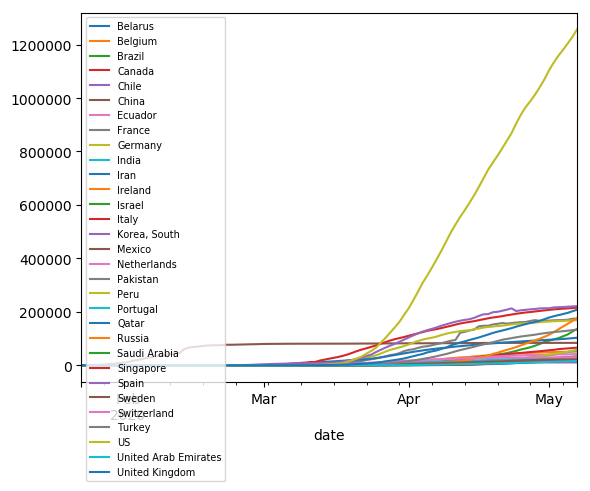

In [29]:
dat = covid_data.pivot(index='date', columns='country', values='confirmed')
dat.plot();
plt.legend(loc='upper left', prop={'size': 7});
plt.show();

국가별 누적확진자 수 그래프를 보면 미국의 경우 1,000,000명 이상의 누적 확진자가 존재하는 것을 확인할 수 있다. 국가별 누적 확진자 수 그래프를 보면 일반 추세가 존재하는 것을 확인할 수 있다. 따라서 일반 차분을 진행한다.

In [30]:
from statsmodels.graphics.tsaplots import acf
dat_diff = dat.diff()
dat_diff.dropna(inplace = True)

ACF를 각 국가별로 계산한다.

In [31]:
mat = np.zeros((dat_diff.shape))

for i in range(0, mat.shape[1]):
    mat[:, i] = acf(dat_diff.iloc[:, i], nlags = mat.shape[0])
    
mat.shape

(106, 31)

유클리디안 거리를 계산한다.

In [32]:
from sklearn.metrics.pairwise import euclidean_distances
print(mat.T.shape)
ucl_dist = euclidean_distances(mat.T)
ucl_dist[:3, :3]

ucl_dist.shape

(31, 106)


(31, 31)

**2. 계층적 군집 분석을 위한 덴드로그램을 작성하시오.**

덴드로그램 작성 전, 계층적 군집분석의 적절한 군집의 수를 정하기 위해 실루엣 계수를 활용한다.

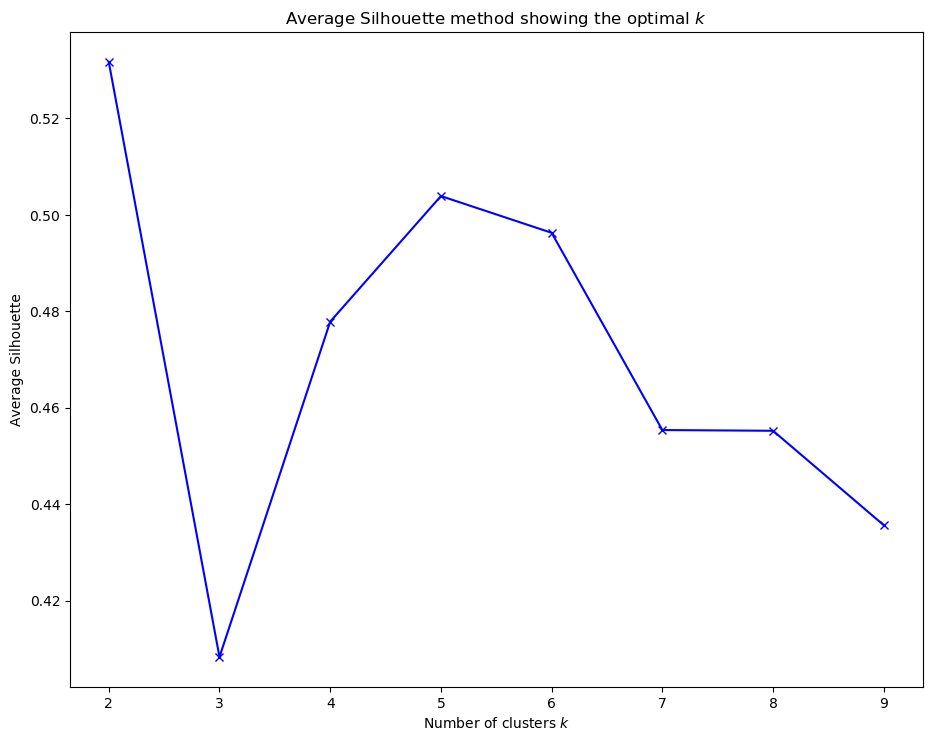

array([0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [33]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
scores = []

for i in range(2,10):
    fit_hk = AgglomerativeClustering(n_clusters=i, linkage = 'ward').fit(ucl_dist)
    score = silhouette_score(ucl_dist, fit_hk.labels_)
    scores.append(score)

plt.figure(figsize=(11,8.5));
plt.plot(range(2,10), np.array(scores), 'bx-');
plt.xlabel('Number of clusters $k$');
plt.ylabel('Average Silhouette');
plt.title('Average Silhouette method showing the optimal $k$');
plt.show();

hk = AgglomerativeClustering(n_clusters = 2, linkage = 'ward')
hk.fit(ucl_dist)
hk.labels_

적절한 군집의 수는 2이다. 덴드로그램을 시각화하면 다음과 같다.

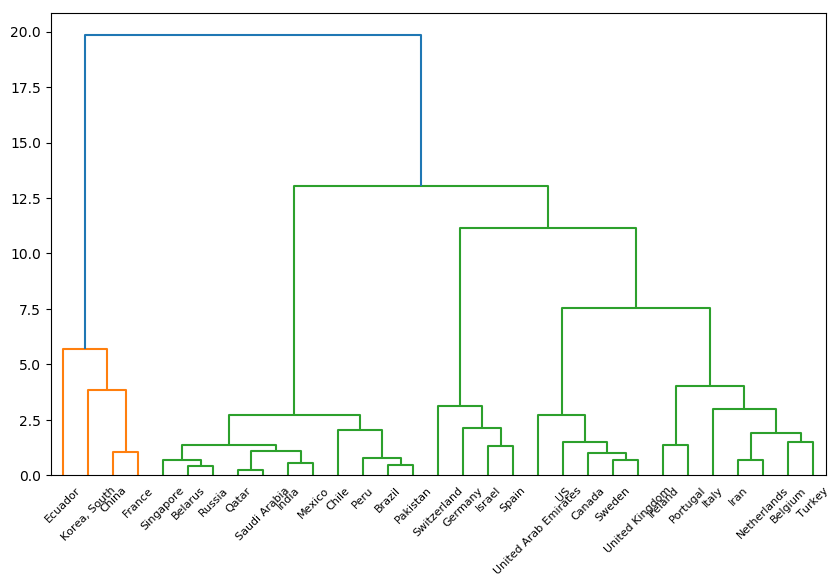

In [34]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(ucl_dist, method="ward");
fig = plt.figure(figsize=(10, 6));
dendrogram(Z, labels = dat.columns);
plt.show();

## 문제 3

슬통제약의 신약이 심장 질환 환자의 혈압을 낮출 수 있는지 검증하려고 한다. 표본으로 15명의 환자가 선택되었으며, 약을 복용하기 전과 복용한 후의 혈압을 측정하였다. 약이 혈압을 실제로 낮추는 것인지 검증하기 위해 유의수준 5%에서 부호 검정을 수행하시오.

In [35]:
dat = pd.read_csv('problem3.csv')

약 복용 전후 혈압차를 계산한다.

In [36]:
diff = dat['before_np'] - dat['after_np']

**1. 귀무가설과 대립가설을 수립하시오.**

-   귀무가설 : 약 복용 전후 혈압차 분포의 중앙값은 0이다.

-   대립가설 : 약 복용 전후 혈압차 분포의 중앙값은 0보다 크다.

**2. 유효한 데이터 개수를 계산하시오.**

혈압이 낮아진 경우

In [37]:
successes = np.sum(diff > 0)
print(f'유효한 데이터 개수 (성공 횟수): {successes}')

유효한 데이터 개수 (성공 횟수): 12


**부호검정을 수행하고 결과를 해석하시오.**

::: callout-note
sign_test()는 단측 가설 옵션이 없으므로, 추가 작업이 필요합니다.
:::

In [38]:
from statsmodels.stats.descriptivestats import sign_test
statistic, p_value_two_tailed = sign_test(diff, mu0=0)
p_value_one_tailed = p_value_two_tailed / 2 if statistic > 0 else 1 - (p_value_two_tailed / 2)
print(f'단측 검정 p-value: {p_value_one_tailed}')

단측 검정 p-value: 0.0064697265625


유의 수준 5%에서 p-value= 0.00647로 작으므로 귀무가설을 기각한다. 따라서 신약이 심장 질환 환자의 혈압을 낮출 수 있다고 판단한다.

## 문제 4

한 마을에서 사람들이 어떤 종류의 운동을 좋아하는지 조사했습니다. 이 마을에서는 세 가지 나이 그룹과 세 가지 운동 종류에 대해 조사를 했습니다. 나이 그룹은 다음과 같습니다.

|        | 축구 | 농구 | 테니스 |
|--------|------|------|--------|
| 청소년 | 15   | 25   | 10     |
| 청년   | 20   | 15   | 25     |
| 중장년 | 30   | 20   | 10     |

조사 결과를 통해 나이 그룹과 운동 종류 간의 관계가 있는지 분석하려고 합니다.

In [39]:
data = pd.DataFrame([[15, 25, 10],
                     [20, 15, 25],
                     [30, 20, 10]],
                    index=['청소년', '청년', '중장년'],
                    columns=['축구', '농구', '테니스'])

print(data)

     축구  농구  테니스
청소년  15  25   10
청년   20  15   25
중장년  30  20   10


**1. 귀무가설과 대립가설을 수립하시오.**

-   귀무가설 : 나이와 운동 선호도 간에는 관계가 없다.

-   대립가설 : 나이와 운동 선호도 간에는 관계가 있다.

**2. 독립일 경우의 기대빈도를 구하시오.**

In [40]:
from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(data)
print("기대빈도:")
print(pd.DataFrame(expected, index=data.index, columns=data.columns))

기대빈도:
            축구         농구        테니스
청소년  19.117647  17.647059  13.235294
청년   22.941176  21.176471  15.882353
중장년  22.941176  21.176471  15.882353


**3. 검정 결과를 해석하시오.**

In [41]:
print(f'카이제곱 통계량: {chi2_stat}')
print(f'p-value: {p_value}')

카이제곱 통계량: 16.570156695156694
p-value: 0.002342188067991256


유의수준 5%에서 p-value = 0.002342로 작으므로, 귀무가설을 기각한다. 따라서 나이와 운동 선호도 간에는 유의미한 관계가 존재한다.